# Module 2 — Lab 1: Data Cleaning, EDA & Preprocessing
## Real Estate Price Prediction — Pune Property Dataset (200 Properties)

---

### Lab Overview

You will work with a real-world dataset of **200 residential properties in Pune, India** from a real estate aggregator platform. The dataset is messy in ways that mirror production data: typos in column names, inconsistent casing, text mixed into numeric fields, binary features encoded as "Yes"/"No" strings, and missing values.

Every cleaning decision you make here directly impacts the model performance ceiling in Lab 3. There is no algorithm that compensates for "2 BHK" and "2BHK" being treated as separate categories.

| Step | What We Do | Why It Matters |
|------|-----------|----------------|
| 1 | Load and inspect raw data | Understand the mess before cleaning |
| 2 | Extract location details | Separate City, State, Country from a single column |
| 3 | Clean each categorical column (one by one) | Reduce noise, standardize categories |
| 4 | Encode binary amenity features | Convert Yes/No strings to 1/0 |
| 5 | Clean numeric fields using regex | Extract numbers from text-mixed columns |
| 6 | Univariate & multivariate EDA | Distribution plots, correlations, per-location analysis |
| 7 | Outlier detection and treatment | IQR clipping to reduce leverage |

### Learning Objectives

By the end of this lab, you will be able to:
1. Inspect a messy real-world dataset column by column before writing any cleaning code
2. Extract structured location information from a composite text field
3. Clean each categorical column individually with before/after validation
4. Handle numeric fields where values are embedded in text strings (regex)
5. Perform univariate and multivariate EDA to inform modeling decisions
6. Detect and treat outliers using IQR and percentile clipping

---

## 1. Environment Setup

> **Google Colab:** Run the cell below as-is.
> **Local Jupyter:** Uncomment the pip install line if packages are not already installed.

In [ ]:
# ── Environment Setup ──
# Uncomment the line below if running locally and packages are not installed
!pip install pandas numpy matplotlib seaborn scipy openpyxl nltk scikit-learn -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', 30)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_rows', None)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print("✅ All libraries imported successfully")
print(f"   pandas: {pd.__version__}")
print(f"   numpy:  {np.__version__}")

✅ All libraries imported successfully
   pandas: 2.2.2
   numpy:  2.0.2


## 2. Load and Inspect the Raw Dataset

The dataset is `Pune Real Estate Data.xlsx` — 200 property listings with 18 columns.

> **Colab:** Upload the file via the Files panel (📁 icon) or mount Google Drive.
> **Local:** Place the file in the same directory as this notebook, or adjust the path below.

In [ ]:
# ── Load Data ──
# Adjust the path based on your environment
DATA_PATH = 'Pune Real Estate Data.xlsx'  # <-- adjust if needed

try:
    df_raw = pd.read_excel(DATA_PATH)
    print(f"✅ Dataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
except FileNotFoundError:
    print("❌ File not found. Please check the path above.")
    raise SystemExit("Upload the dataset before proceeding.")

✅ Dataset loaded: 200 rows × 18 columns


In [ ]:
df_raw.head(7)

,Sr. No.,Location,Sub-Area,Propert Type,Property Area in Sq. Ft.,Price in lakhs,Price in Millions,Company Name,TownShip Name/ Society Name,Total TownShip Area in Acres,ClubHouse,School / University in Township,Hospital in TownShip,Mall in TownShip,Park / Jogging track,Swimming Pool,Gym,Description
0,1,"Pune, Maharashtra, India",Bavdhan,1 BHK,492,39,3.9,Shapoorji Paloonji,Vanaha,1000.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Shapoorji Paloonji comunity located in the suburbs of Bavadhan locality is s...
1,2,"Pune, Maharashtra, India",Bavdhan,2 BHK,774,65,6.5,Shapoorji Paloonji,Vanaha,1000.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Vanaha Township located near the lonavala hill range. Offers a very greenery...
2,3,"Pune, Maharashtra, India",Bavdhan,3 BHK,889,74,7.4,Shapoorji Paloonji,Vanaha,1000.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Vanaha Society is suitable for all aged group people with a playareafor kids...
3,4,"Pune, Maharashtra, India",Bavdhan,3 BHK Grand,1018,89,8.9,Shapoorji Paloonji,Vanaha,1000.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,"Vanaha township are offering 3BHK grand prpoerties at Bavdhan area, pune. Th..."
4,5,"Pune, Maharashtra, India",Mahalunge,2BHK,743,74,7.4,Godrej Properties,Godrej Hills retreat,100.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,"The area is a hub of prestigious schools like Bishop’s High School, Vibgyor ..."
5,6,"Pune, Maharashtra, India",Mahalunge,3BHK,975,95,9.5,Godrej Properties,Godrej Hills retreat,100.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,"Strategically located in Mahalunge, Pune's quaint, nature-loving and yet, we..."
6,7,"Pune, Maharashtra, India",Balewadi,2BHK,877 to 912,75,7.5,ANP CORP,ANP Universe,25.0,Yes,No,No,No,Yes,Yes,Yes,"The Project Boasts 6 Elegant Towers Of 11 & 12 Stories, Offering 2 & 3 Bedro..."


In [ ]:
df_raw.tail()

,Sr. No.,Location,Sub-Area,Propert Type,Property Area in Sq. Ft.,Price in lakhs,Price in Millions,Company Name,TownShip Name/ Society Name,Total TownShip Area in Acres,ClubHouse,School / University in Township,Hospital in TownShip,Mall in TownShip,Park / Jogging track,Swimming Pool,Gym,Description
195,196,"Pune, Maharashtra, India",BANER,3bhk,1300 to 1400,160,16.000,SUPREME,SUPREME ESTIA,5.0,yes,no,no,no,yes,yes,yes,SUPREME ESTIA - the name itself emanates a feeling of exclusivity and magnif...
196,197,"Pune, Maharashtra, India",BANER,4bhk,1600 +,230,23.000,SUPREME,SUPREME ESTIA,5.0,yes,no,no,no,yes,yes,yes,Not every day would you come across a development that stimulates the soul a...
197,198,"Pune, Maharashtra, India",BANER,2 bhk,769 to 809,95,9.500,Tejraaj Group,TEJ ELEVIA,2.5,no,no,no,no,yes,yes,yes,A lifestyle of abundance that fourishes amidst all the essentials of a bount...
198,199,"Pune, Maharashtra, India",BANER,3 bhk,1101 to 1113,135,13.500,Tejraaj Group,TEJ ELEVIA,2.5,no,no,no,no,yes,yes,yes,"We are proud of it.We are sure, you will fall in love with it too. After all..."
199,200,"Pune, Maharashtra, India",BANER,2bhk,776,90.68,9.068,VTP Reality,vtp solitaire,NaN,yes,no,no,no,yes,yes,yes,"A beautiful collection of ultra-modern homes, which will defi nitely exceed ..."


In [ ]:
df_raw.sample(5)

,Sr. No.,Location,Sub-Area,Propert Type,Property Area in Sq. Ft.,Price in lakhs,Price in Millions,Company Name,TownShip Name/ Society Name,Total TownShip Area in Acres,ClubHouse,School / University in Township,Hospital in TownShip,Mall in TownShip,Park / Jogging track,Swimming Pool,Gym,Description
114,115,"Pune, Maharashtra, India",Karvanagar,2bhk,735,111,11.100,maha anand Pinnac associates,River Dale Residency,NaN,no,no,no,no,yes,no,yes,"River Dale Residency is a residential development in Karvanagar, Pune. The p..."
58,59,"Pune, Maharashtra, India",hadapsar,2 bhk,753,73.5,7.350,proviso group,lesiure Town,NaN,no,No,No,No,yes,yes,Yes,"The robust infrastructure, quality materials, thoughtful design, and impress..."
101,102,"Pune, Maharashtra, India",BT Kawade RD,2bhk,871,96,9.600,kundan Spaces,Eternia 2.0,NaN,yes,no,no,no,yes,Yes,yes,"Expensive green spaces, enriching facilities, extravagant amenities and much..."
111,112,"Pune, Maharashtra, India",handewadi,2bhk,655,44.44,4.444,Lush Life,Impero,NaN,no,no,no,no,yes,no,no,A grand entrance gate with security cabin and well paved entrance avenue wit...
54,55,"Pune, Maharashtra, India",tathawade,2bhk,732,60,6.000,ravima ventures,newton homes,NaN,no,No,No,No,Yes,no,Yes,"Newton home's – 3 BHK flats, location translates into an advantageous invest..."


In [ ]:
df_raw.shape

(200, 18)

In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Sr. No.                           200 non-null    int64  
 1   Location                          200 non-null    object 
 2   Sub-Area                          200 non-null    object 
 3   Propert Type                      200 non-null    object 
 4   Property Area in Sq. Ft.          200 non-null    object 
 5   Price in lakhs                    200 non-null    object 
 6   Price in Millions                 199 non-null    float64
 7   Company Name                      200 non-null    object 
 8   TownShip Name/ Society Name       200 non-null    object 
 9   Total TownShip Area in Acres      51 non-null     float64
 10  ClubHouse                         200 non-null    object 
 11  School / University in Township   200 non-null    object 
 12  Hospital

In [ ]:
df_raw.columns

Index(['Sr. No.', 'Location', 'Sub-Area', 'Propert Type',
       'Property Area in Sq. Ft.', 'Price in lakhs', 'Price in Millions',
       'Company Name', 'TownShip Name/ Society Name',
       'Total TownShip Area in Acres', 'ClubHouse',
       'School / University in Township ', 'Hospital in TownShip',
       'Mall in TownShip', 'Park / Jogging track', 'Swimming Pool', 'Gym',
       'Description'],
      dtype='object')

In [ ]:
# ── First Look: What are we working with? ──
print("=== Column Names ===")
for i, col in enumerate(df_raw.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n=== Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns ===")
print(f"\n=== Data Types ===")
print(df_raw.dtypes)

=== Column Names ===
   1. Sr. No.
   2. Location
   3. Sub-Area
   4. Propert Type
   5. Property Area in Sq. Ft.
   6. Price in lakhs
   7. Price in Millions
   8. Company Name
   9. TownShip Name/ Society Name
  10. Total TownShip Area in Acres
  11. ClubHouse
  12. School / University in Township 
  13. Hospital in TownShip
  14. Mall in TownShip
  15. Park / Jogging track
  16. Swimming Pool
  17. Gym
  18. Description

=== Shape: 200 rows × 18 columns ===

=== Data Types ===
Sr. No.                               int64
Location                             object
Sub-Area                             object
Propert Type                         object
Property Area in Sq. Ft.             object
Price in lakhs                       object
Price in Millions                   float64
Company Name                         object
TownShip Name/ Society Name          object
Total TownShip Area in Acres        float64
ClubHouse                            object
School / University in Townshi

In [ ]:
len(df_raw)

200

In [ ]:
# ── Missing Values Overview ──
print("=== Missing Values ===")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(1)
missing_df = pd.DataFrame({'Count': missing, 'Pct (%)': missing_pct})

print(missing_df[missing_df['Count'] > 0])
print(f"\nTotal missing cells: {df_raw.isnull().sum().sum()} out of {df_raw.size}")

=== Missing Values ===
                              Count  Pct (%)
Price in Millions                 1      0.5
Total TownShip Area in Acres    149     74.5

Total missing cells: 150 out of 3600


In [ ]:
# ── Quick peek at the raw data ──
print("=== First 3 Rows (transposed for readability) ===")
display(df_raw.head(3).T)

=== First 3 Rows (transposed for readability) ===


,0,1,2
Sr. No.,1,2,3
Location,"Pune, Maharashtra, India","Pune, Maharashtra, India","Pune, Maharashtra, India"
Sub-Area,Bavdhan,Bavdhan,Bavdhan
Propert Type,1 BHK,2 BHK,3 BHK
Property Area in Sq. Ft.,492,774,889
Price in lakhs,39,65,74
Price in Millions,3.9,6.5,7.4
Company Name,Shapoorji Paloonji,Shapoorji Paloonji,Shapoorji Paloonji
TownShip Name/ Society Name,Vanaha,Vanaha,Vanaha
Total TownShip Area in Acres,1000.0,1000.0,1000.0


## 3. Column-by-Column Data Cleaning

**The discipline:** Inspect each column → understand the mess → write a targeted cleaner → validate before/after. We DO NOT write a generic cleaner and hope it works.

We'll work on a copy of the raw data.

In [ ]:
# Work on a copy — never modify the raw DataFrame
df = df_raw.copy()

### 3.1 Location: Extract City, State, Country

In [ ]:
# ── Inspect the Location column ──
print("Unique locations:")
print(df['Location'].unique())
print(f"\nAll entries are: '{df['Location'].iloc[0]}'")
print("→ A single composite value — we need to split it into City, State, Country")

Unique locations:
['Pune, Maharashtra, India']

All entries are: 'Pune, Maharashtra, India'
→ A single composite value — we need to split it into City, State, Country


In [ ]:
loc = "Pune, Maharashtra, India"
loc.split(",")[1].lower().strip()

'maharashtra'

In [ ]:
# ── Extract City, State, Country ──
df['City'] = df['Location'].apply(lambda x: x.split(',')[0].lower().strip())
df['State'] = df['Location'].apply(lambda x: x.split(',')[1].lower().strip())
df['Country'] = df['Location'].apply(lambda x: x.split(',')[2].lower().strip())

print("After extraction:")
print(f"  Cities:    {df['City'].unique()}")
print(f"  States:    {df['State'].unique()}")
print(f"  Countries: {df['Country'].unique()}")

After extraction:
  Cities:    ['pune']
  States:    ['maharashtra']
  Countries: ['india']


In [ ]:
df.head()

,Sr. No.,Location,Sub-Area,Propert Type,Property Area in Sq. Ft.,Price in lakhs,Price in Millions,Company Name,TownShip Name/ Society Name,Total TownShip Area in Acres,ClubHouse,School / University in Township,Hospital in TownShip,Mall in TownShip,Park / Jogging track,Swimming Pool,Gym,Description,City,State,Country
0,1,"Pune, Maharashtra, India",Bavdhan,1 BHK,492,39,3.9,Shapoorji Paloonji,Vanaha,1000.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Shapoorji Paloonji comunity located in the suburbs of Bavadhan locality is s...,pune,maharashtra,india
1,2,"Pune, Maharashtra, India",Bavdhan,2 BHK,774,65,6.5,Shapoorji Paloonji,Vanaha,1000.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Vanaha Township located near the lonavala hill range. Offers a very greenery...,pune,maharashtra,india
2,3,"Pune, Maharashtra, India",Bavdhan,3 BHK,889,74,7.4,Shapoorji Paloonji,Vanaha,1000.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Vanaha Society is suitable for all aged group people with a playareafor kids...,pune,maharashtra,india
3,4,"Pune, Maharashtra, India",Bavdhan,3 BHK Grand,1018,89,8.9,Shapoorji Paloonji,Vanaha,1000.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,"Vanaha township are offering 3BHK grand prpoerties at Bavdhan area, pune. Th...",pune,maharashtra,india
4,5,"Pune, Maharashtra, India",Mahalunge,2BHK,743,74,7.4,Godrej Properties,Godrej Hills retreat,100.0,Yes,Yes,Yes,Yes,Yes,Yes,Yes,"The area is a hub of prestigious schools like Bishop’s High School, Vibgyor ...",pune,maharashtra,india


### 3.2 Property Type

Note: The original column is named `"Propert Type"` (a typo in the source data!). Real-world data has these — don't assume clean column names.

In [ ]:
# ── Before cleaning ──
print(f"Column name: '{df.columns[3]}'  ← note the typo!")
print(f"\nUnique values BEFORE cleaning: {df['Propert Type'].nunique()}")
print(df['Propert Type'].value_counts())

Column name: 'Propert Type'  ← note the typo!

Unique values BEFORE cleaning: 33
Propert Type
2bhk           56
3BHK           28
3bhk           19
2BHK           18
2 bhk          16
3 bhk          10
1BHK            9
1bhk            7
1 BHK           3
2bhk            3
2.5 BHK         2
3 BHK           2
3.5bhk          2
2.5 bhk         2
4 bhk           2
3.5 bhk         2
5BHK            2
2 bhk           2
shop            1
3  bhk          1
6BHK            1
3 BHK Grand     1
2 BHK           1
4BHK            1
1 bhk           1
3 BHK           1
3bhk            1
2+2 bhk         1
3+2bhk          1
5 bhk           1
1bhk            1
4.5bhk          1
4bhk            1
Name: count, dtype: int64


In [ ]:
# ── Clean: extract the numeric bedroom count using regex ──
numbers_pattern = re.compile(r"[-+]?(\d*\.\d+|\d+)")

def clean_property_type(val):
    """Extract bedroom count from property type string. Returns float or 0."""
    matches = numbers_pattern.findall(str(val))
    if len(matches) > 0:
        return float(matches[0])
    return 0.0

df['Property Type Cleaned'] = df['Propert Type'].apply(clean_property_type)

print(f"Unique values AFTER cleaning: {df['Property Type Cleaned'].nunique()}")
print(df['Property Type Cleaned'].value_counts().sort_index())
print(f"\nReduced from {df['Propert Type'].nunique()} → {df['Property Type Cleaned'].nunique()} categories")

Unique values AFTER cleaning: 10
Property Type Cleaned
0.0     1
1.0    21
2.0    97
2.5     4
3.0    64
3.5     4
4.0     4
4.5     1
5.0     3
6.0     1
Name: count, dtype: int64

Reduced from 33 → 10 categories


### 3.3 Sub-Area (Neighbourhood)

In [ ]:
# ── Before cleaning ──
print(f"Unique sub-areas BEFORE cleaning: {df['Sub-Area'].nunique()}")
print(df['Sub-Area'].value_counts().head(10))

Unique sub-areas BEFORE cleaning: 39
Sub-Area
Kharadi           16
handewadi         11
BT Kawade RD      10
Hinjewadi          9
wadgaon sheri      9
Ravet              9
hadapsar           8
NIBM               8
BANER              7
vimannagar         6
Name: count, dtype: int64


In [ ]:
# ── Clean: lowercase + strip whitespace ──
df['Sub-Area Cleaned'] = df['Sub-Area'].apply(lambda x: x.lower().strip())

print(f"\nUnique sub-areas AFTER cleaning: {df['Sub-Area Cleaned'].nunique()}")
print(f"Reduced from {df['Sub-Area'].nunique()} → {df['Sub-Area Cleaned'].nunique()}")
print(f"\nTop 10 sub-areas:")
print(df['Sub-Area Cleaned'].value_counts().head(10))


Unique sub-areas AFTER cleaning: 34
Reduced from 39 → 34

Top 10 sub-areas:
Sub-Area Cleaned
kharadi          16
ravet            12
baner            12
handewadi        11
bt kawade rd     10
bavdhan          10
mahalunge         9
hinjewadi         9
wadgaon sheri     9
hadapsar          8
Name: count, dtype: int64


### 3.4 Company Name

In [ ]:
# ── Before cleaning ──
print(f"Unique companies BEFORE cleaning: {df['Company Name'].nunique()}")

# ── Clean ──
df['Company Name Cleaned'] = df['Company Name'].apply(lambda x: x.lower().strip())

print(f"Unique companies AFTER cleaning: {df['Company Name Cleaned'].nunique()}")
print(f"\nTop 10 companies:")
print(df['Company Name Cleaned'].value_counts().head(10))

Unique companies BEFORE cleaning: 37
Unique companies AFTER cleaning: 37

Top 10 companies:
Company Name Cleaned
mantra properties            29
kundan spaces                14
unique properties            11
jhala group                  10
shapoorji paloonji           10
vijaya laxmi creations        9
puraniks                      8
ravima ventures               7
vtp reality                   6
porwal & anand develkoper     6
Name: count, dtype: int64


### 3.5 Township / Society Name

In [ ]:
# ── Before cleaning ──
print(f"Unique townships BEFORE cleaning: {df['TownShip Name/ Society Name'].nunique()}")

# ── Clean ──
df['TownShip Cleaned'] = df['TownShip Name/ Society Name'].apply(lambda x: x.lower().strip())

print(f"Unique townships AFTER cleaning: {df['TownShip Cleaned'].nunique()}")
print(f"\nTop 10 townships:")
print(df['TownShip Cleaned'].value_counts().head(10))

Unique townships BEFORE cleaning: 54
Unique townships AFTER cleaning: 54

Top 10 townships:
TownShip Cleaned
mantra 29 gold         13
eternia 2.0             8
newton homes            6
k ville                 6
brookefield willows     6
mantra sky tower        6
parklane urbanjoy       6
abitante fiore          6
satyam shery            6
oxy beaumonde           6
Name: count, dtype: int64


### 3.6 Description (Text Column)

In [ ]:
# ── Clean: lowercase + strip ──
df['Description Cleaned'] = df['Description'].apply(lambda x: x.lower().strip())

print("Sample descriptions (cleaned):")
for desc in df['Description Cleaned'].head(3):
    print(f"  → {desc[:100]}...")

Sample descriptions (cleaned):
  → shapoorji paloonji comunity located in the suburbs of bavadhan locality is situated in a pleasant en...
  → vanaha township located near the lonavala hill range. offers a very greenery filled environment and ...
  → vanaha society is suitable for all aged group people with a playareafor kids, woodland for the teen'...


### 3.7 Binary Amenity Features

Seven columns contain Yes/No values for amenities. We encode them as 1/0 integers.

In [ ]:
# ── Encode all binary amenity columns ──
binary_cols = {
    'ClubHouse': 'ClubHouse Cleaned',
    'School / University in Township ': 'School Cleaned',
    'Hospital in TownShip': 'Hospital Cleaned',
    'Mall in TownShip': 'Mall Cleaned',
    'Park / Jogging track': 'Park Cleaned',
    'Swimming Pool': 'Pool Cleaned',
    'Gym': 'Gym Cleaned',
}

for raw_col, clean_col in binary_cols.items():
    # Inspect unique values first
    unique_vals = df[raw_col].apply(lambda x: x.lower().strip()).unique()
    # Encode
    df[clean_col] = df[raw_col].apply(lambda x: x.lower().strip()).map({'yes': 1, 'no': 0})
    # Handle unexpected values (map returns NaN for unmapped)
    unmapped = df[clean_col].isnull().sum()
    if unmapped > 0:
        print(f"  ⚠️  {raw_col}: {unmapped} unmapped values (unique: {unique_vals})")
        df[clean_col] = df[clean_col].fillna(0).astype(int)
    else:
        df[clean_col] = df[clean_col].astype(int)
    print(f"  ✅ {raw_col:40s} → {clean_col:20s}  (1s: {df[clean_col].sum()}, 0s: {(df[clean_col]==0).sum()})")

  ✅ ClubHouse                                → ClubHouse Cleaned     (1s: 148, 0s: 52)
  ✅ School / University in Township          → School Cleaned        (1s: 6, 0s: 194)
  ✅ Hospital in TownShip                     → Hospital Cleaned      (1s: 6, 0s: 194)
  ✅ Mall in TownShip                         → Mall Cleaned          (1s: 6, 0s: 194)
  ✅ Park / Jogging track                     → Park Cleaned          (1s: 196, 0s: 4)
  ✅ Swimming Pool                            → Pool Cleaned          (1s: 127, 0s: 73)
  ✅ Gym                                      → Gym Cleaned           (1s: 162, 0s: 38)


### 3.8 Property Area (Numeric — Text-Mixed)

The `Property Area in Sq. Ft.` column contains strings like `"1200"`, `"800 - 1200"` (ranges), and potentially text. We need regex to extract numbers and handle ranges by averaging.

In [ ]:
# ── Inspect ──
print("Sample raw area values:")
print(df['Property Area in Sq. Ft.'].sample(10).tolist())
print(f"\nDtype: {df['Property Area in Sq. Ft.'].dtype} ← it's object/text, not numeric!")

Sample raw area values:
[1671, 968, 727, 1163, 616, 1180, 629, 900, 684, '769 to 809 ']

Dtype: object ← it's object/text, not numeric!


In [ ]:
# ── Clean: extract numbers, average ranges ──
def clean_area(val):
    """Extract area from text. If range (e.g., '800 - 1200'), return average."""
    nums = numbers_pattern.findall(str(val))
    if len(nums) == 1:
        return float(nums[0])
    elif len(nums) == 2:
        return (float(nums[0]) + float(nums[1])) / 2
    elif len(nums) > 2:
        return float(nums[0])  # take first if multiple
    return np.nan

df['Area Cleaned'] = df['Property Area in Sq. Ft.'].apply(clean_area)

print(f"Successfully extracted: {df['Area Cleaned'].notna().sum()} / {len(df)} values")
print(f"Missing after extraction: {df['Area Cleaned'].isna().sum()}")
print(f"\nArea statistics:")
print(df['Area Cleaned'].describe())

# Show some before/after pairs
print("\nBefore → After:")
sample_idx = df.sample(5, random_state=42).index
for idx in sample_idx:
    raw = df.loc[idx, 'Property Area in Sq. Ft.']
    clean = df.loc[idx, 'Area Cleaned']
    print(f"  '{raw}' → {clean}")

Successfully extracted: 200 / 200 values
Missing after extraction: 0

Area statistics:
count     200.000000
mean      894.060000
std       380.256831
min       113.000000
25%       670.000000
50%       800.500000
75%      1041.250000
max      2447.000000
Name: Area Cleaned, dtype: float64

Before → After:
  '1463' → 1463.0
  '423' → 423.0
  '1088' → 1088.0
  '968' → 968.0
  '1772' → 1772.0


### 3.9 Price (Numeric — Text-Mixed)

In [ ]:
# ── Inspect ──
print("Sample raw price values:")
print(df['Price in lakhs'].sample(10).tolist())
print(f"\nDtype: {df['Price in lakhs'].dtype}")

Sample raw price values:
[930, 146, 84, 175, 65, 118, 129, 'Null', 47.59, 70]

Dtype: object


In [ ]:
# ── Clean: extract price as float ──
def clean_price(val):
    """Extract numeric price from text-mixed field."""
    nums = numbers_pattern.findall(str(val))
    if len(nums) > 0:
        return float(nums[0])
    return np.nan

df['Price Cleaned'] = df['Price in lakhs'].apply(clean_price)

print(f"Successfully extracted: {df['Price Cleaned'].notna().sum()} / {len(df)} values")
print(f"Missing after extraction: {df['Price Cleaned'].isna().sum()}")
print(f"\nPrice statistics (in lakhs ₹):")
print(df['Price Cleaned'].describe())

Successfully extracted: 199 / 200 values
Missing after extraction: 1

Price statistics (in lakhs ₹):
count    199.000000
mean      95.258291
std      101.869843
min       13.190000
25%       51.500000
50%       70.000000
75%       99.435000
max      930.000000
Name: Price Cleaned, dtype: float64


### 3.10 Assemble the Cleaned DataFrame

In [ ]:
# ── Select only cleaned columns ──
clean_cols = [
    'City', 'State', 'Country',
    'Property Type Cleaned', 'Sub-Area Cleaned',
    'Company Name Cleaned', 'TownShip Cleaned',
    'Description Cleaned',
    'ClubHouse Cleaned', 'School Cleaned', 'Hospital Cleaned',
    'Mall Cleaned', 'Park Cleaned', 'Pool Cleaned', 'Gym Cleaned',
    'Area Cleaned', 'Price Cleaned'
]

df_clean = df[clean_cols].copy()

# Drop rows where price is NaN (can't train without a target)
before = len(df_clean)
df_clean = df_clean.dropna(subset=['Price Cleaned'])
print(f"Dropped {before - len(df_clean)} rows with missing price")
print(f"\nCleaned DataFrame: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"Columns: {df_clean.columns.tolist()}")
display(df_clean.head(3))

Dropped 1 rows with missing price

Cleaned DataFrame: 199 rows × 17 columns
Columns: ['City', 'State', 'Country', 'Property Type Cleaned', 'Sub-Area Cleaned', 'Company Name Cleaned', 'TownShip Cleaned', 'Description Cleaned', 'ClubHouse Cleaned', 'School Cleaned', 'Hospital Cleaned', 'Mall Cleaned', 'Park Cleaned', 'Pool Cleaned', 'Gym Cleaned', 'Area Cleaned', 'Price Cleaned']


,City,State,Country,Property Type Cleaned,Sub-Area Cleaned,Company Name Cleaned,TownShip Cleaned,Description Cleaned,ClubHouse Cleaned,School Cleaned,Hospital Cleaned,Mall Cleaned,Park Cleaned,Pool Cleaned,Gym Cleaned,Area Cleaned,Price Cleaned
0,pune,maharashtra,india,1.0,bavdhan,shapoorji paloonji,vanaha,shapoorji paloonji comunity located in the suburbs of bavadhan locality is s...,1,1,1,1,1,1,1,492.0,39.0
1,pune,maharashtra,india,2.0,bavdhan,shapoorji paloonji,vanaha,vanaha township located near the lonavala hill range. offers a very greenery...,1,1,1,1,1,1,1,774.0,65.0
2,pune,maharashtra,india,3.0,bavdhan,shapoorji paloonji,vanaha,vanaha society is suitable for all aged group people with a playareafor kids...,1,1,1,1,1,1,1,889.0,74.0


## 4. Univariate Analysis

Now we have clean data — let's understand each variable's distribution before looking at relationships.

Unique sub-areas: 34


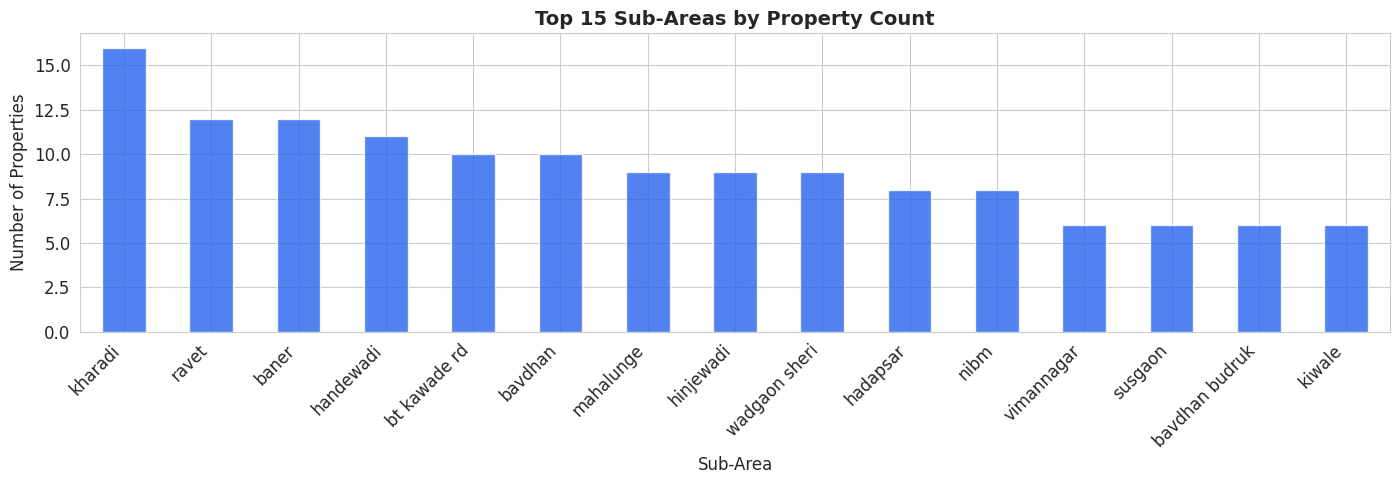

In [ ]:
# ── 4.1 Distribution of Sub-Areas ──
print(f"Unique sub-areas: {df_clean['Sub-Area Cleaned'].nunique()}")

fig, ax = plt.subplots(figsize=(14, 5))
top_areas = df_clean['Sub-Area Cleaned'].value_counts().head(15)
top_areas.plot(kind='bar', color='#2563eb', alpha=0.8, ax=ax, edgecolor='white')
ax.set_title('Top 15 Sub-Areas by Property Count', fontweight='bold', fontsize=14)
ax.set_xlabel('Sub-Area')
ax.set_ylabel('Number of Properties')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

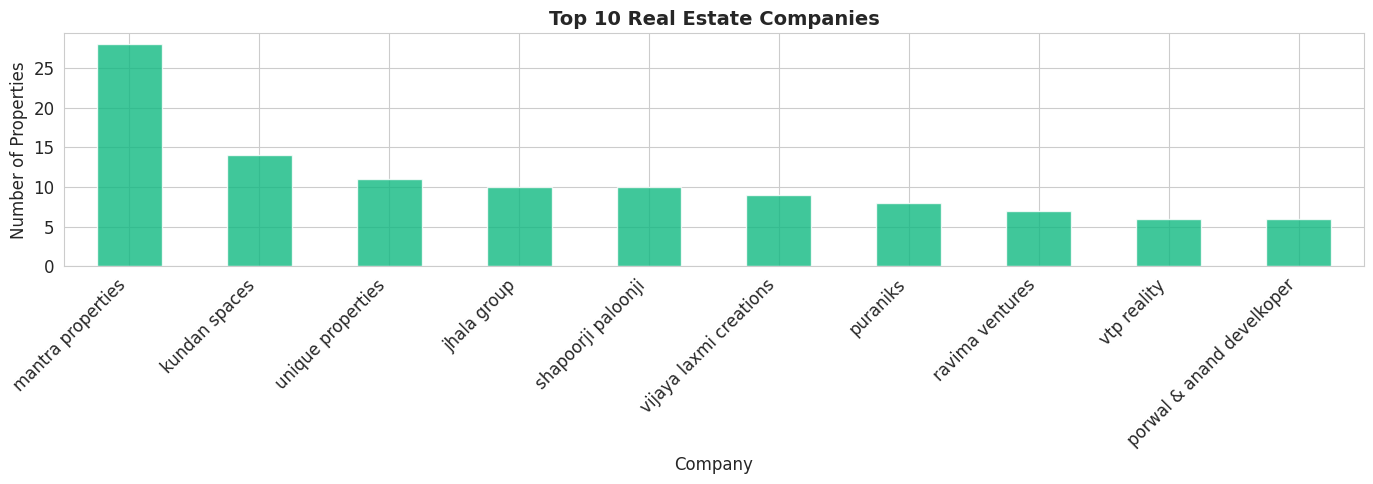

In [ ]:
# ── 4.2 Distribution of Companies ──
fig, ax = plt.subplots(figsize=(14, 5))
top_companies = df_clean['Company Name Cleaned'].value_counts().head(10)
top_companies.plot(kind='bar', color='#10b981', alpha=0.8, ax=ax, edgecolor='white')
ax.set_title('Top 10 Real Estate Companies', fontweight='bold', fontsize=14)
ax.set_xlabel('Company')
ax.set_ylabel('Number of Properties')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

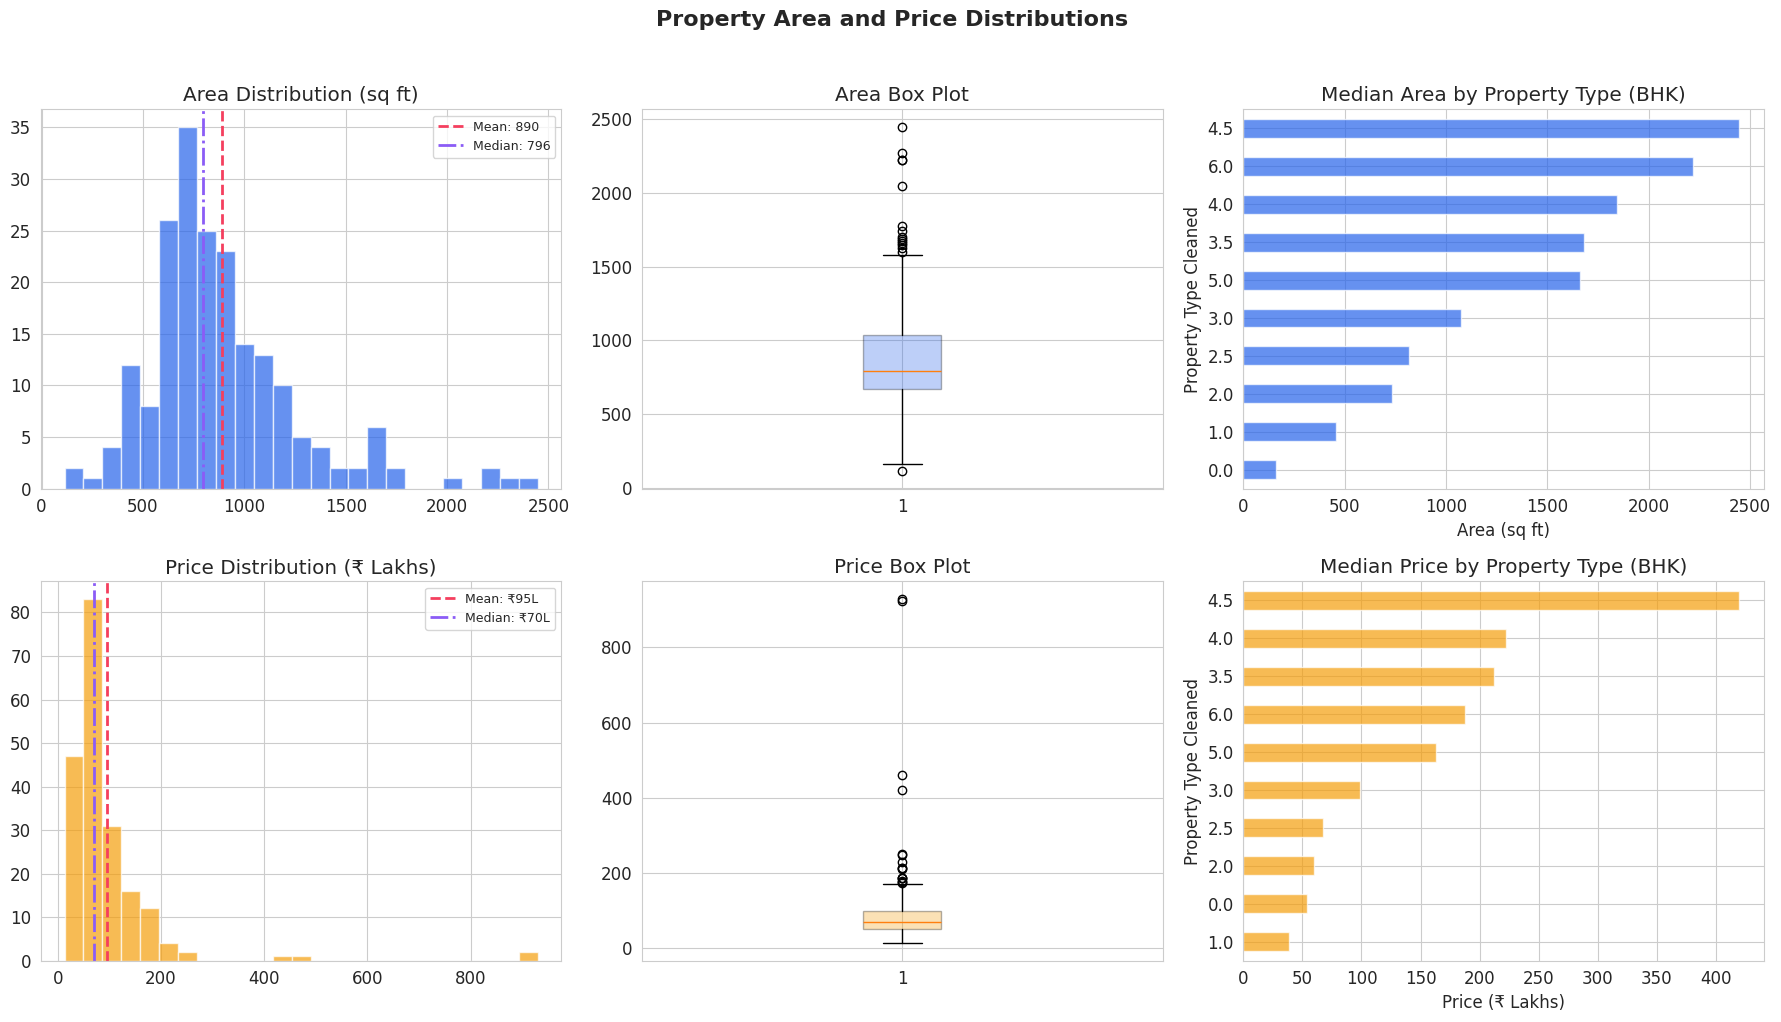

Area  — Skewness: 1.45, Kurtosis: 3.11
Price — Skewness: 6.00, Kurtosis: 44.66


In [ ]:
# ── 4.3 Distribution of Property Area and Price ──
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Area: histogram, boxplot, by property type
axes[0, 0].hist(df_clean['Area Cleaned'].dropna(), bins=25, color='#2563eb', alpha=0.7, edgecolor='white')
axes[0, 0].axvline(df_clean['Area Cleaned'].mean(), color='#f43f5e', ls='--', lw=2, label=f"Mean: {df_clean['Area Cleaned'].mean():.0f}")
axes[0, 0].axvline(df_clean['Area Cleaned'].median(), color='#8b5cf6', ls='-.', lw=2, label=f"Median: {df_clean['Area Cleaned'].median():.0f}")
axes[0, 0].set_title('Area Distribution (sq ft)')
axes[0, 0].legend(fontsize=9)

axes[0, 1].boxplot(df_clean['Area Cleaned'].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#2563eb', alpha=0.3))
axes[0, 1].set_title('Area Box Plot')

# Area by property type
area_by_type = df_clean.groupby('Property Type Cleaned')['Area Cleaned'].median().sort_values()
area_by_type.plot(kind='barh', color='#2563eb', alpha=0.7, ax=axes[0, 2])
axes[0, 2].set_title('Median Area by Property Type (BHK)')
axes[0, 2].set_xlabel('Area (sq ft)')

# Price: histogram, boxplot, by property type
axes[1, 0].hist(df_clean['Price Cleaned'].dropna(), bins=25, color='#f59e0b', alpha=0.7, edgecolor='white')
axes[1, 0].axvline(df_clean['Price Cleaned'].mean(), color='#f43f5e', ls='--', lw=2, label=f"Mean: ₹{df_clean['Price Cleaned'].mean():.0f}L")
axes[1, 0].axvline(df_clean['Price Cleaned'].median(), color='#8b5cf6', ls='-.', lw=2, label=f"Median: ₹{df_clean['Price Cleaned'].median():.0f}L")
axes[1, 0].set_title('Price Distribution (₹ Lakhs)')
axes[1, 0].legend(fontsize=9)

axes[1, 1].boxplot(df_clean['Price Cleaned'].dropna(), vert=True, patch_artist=True,
                   boxprops=dict(facecolor='#f59e0b', alpha=0.3))
axes[1, 1].set_title('Price Box Plot')

price_by_type = df_clean.groupby('Property Type Cleaned')['Price Cleaned'].median().sort_values()
price_by_type.plot(kind='barh', color='#f59e0b', alpha=0.7, ax=axes[1, 2])
axes[1, 2].set_title('Median Price by Property Type (BHK)')
axes[1, 2].set_xlabel('Price (₹ Lakhs)')

plt.suptitle('Property Area and Price Distributions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"Area  — Skewness: {df_clean['Area Cleaned'].skew():.2f}, Kurtosis: {df_clean['Area Cleaned'].kurtosis():.2f}")
print(f"Price — Skewness: {df_clean['Price Cleaned'].skew():.2f}, Kurtosis: {df_clean['Price Cleaned'].kurtosis():.2f}")

## 5. Multivariate Analysis

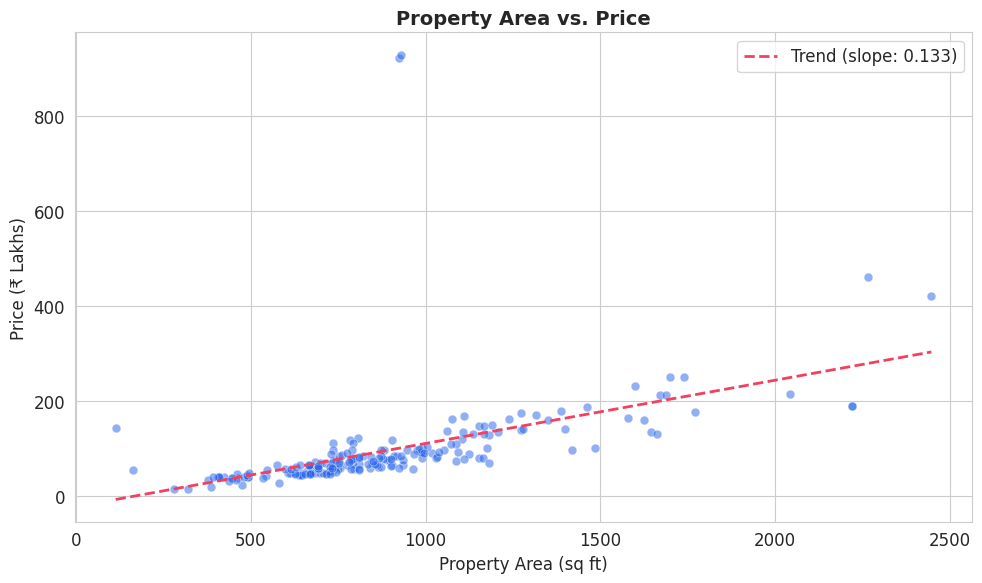

Correlation (Area vs Price): 0.493


In [ ]:
# ── 5.1 Area vs. Price scatter plot ──
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df_clean['Area Cleaned'], df_clean['Price Cleaned'],
           alpha=0.5, color='#2563eb', s=40, edgecolors='white', linewidth=0.5)
ax.set_xlabel('Property Area (sq ft)', fontsize=12)
ax.set_ylabel('Price (₹ Lakhs)', fontsize=12)
ax.set_title('Property Area vs. Price', fontweight='bold', fontsize=14)

# Fit and show trend line
z = np.polyfit(df_clean['Area Cleaned'].dropna(), df_clean['Price Cleaned'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df_clean['Area Cleaned'].min(), df_clean['Area Cleaned'].max(), 100)
ax.plot(x_line, p(x_line), color='#f43f5e', linewidth=2, linestyle='--', label=f'Trend (slope: {z[0]:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

corr = df_clean['Area Cleaned'].corr(df_clean['Price Cleaned'])
print(f"Correlation (Area vs Price): {corr:.3f}")

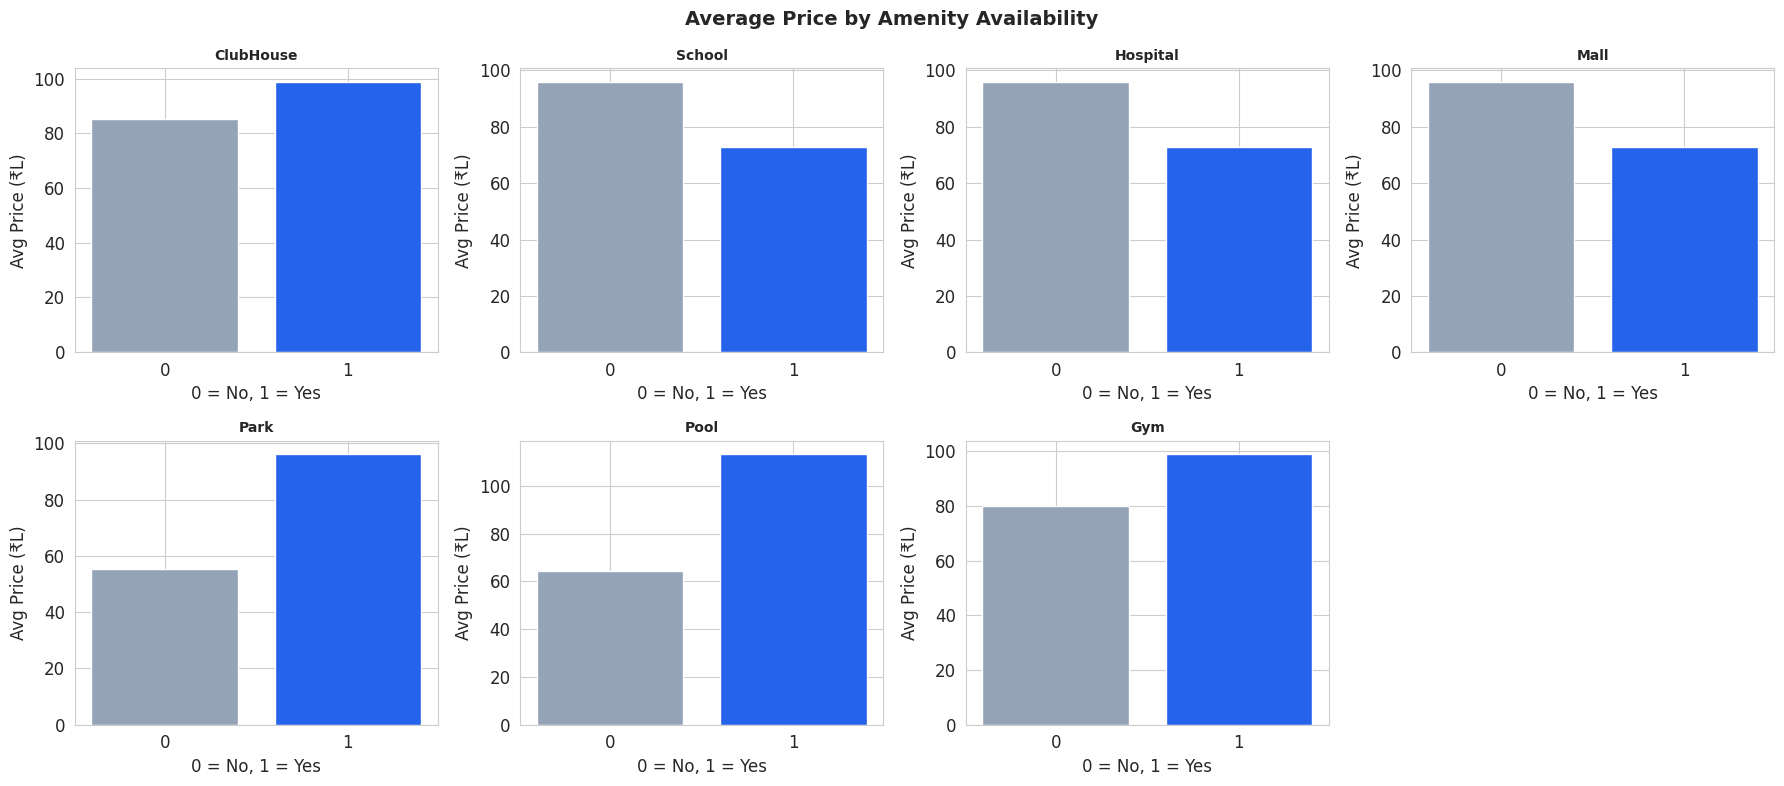

Top amenities by price premium:
  Pool: +₹48.7 lakhs when available
  Park: +₹40.8 lakhs when available
  Gym: +₹18.8 lakhs when available


In [ ]:
# ── 5.2 Amenity columns vs. Price ──
amenity_cols = ['ClubHouse Cleaned', 'School Cleaned', 'Hospital Cleaned',
                'Mall Cleaned', 'Park Cleaned', 'Pool Cleaned', 'Gym Cleaned']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(amenity_cols):
    means = df_clean.groupby(col)['Price Cleaned'].mean()
    axes[i].bar(means.index.astype(str), means.values,
                color=['#94a3b8', '#2563eb'], edgecolor='white')
    axes[i].set_title(col.replace(' Cleaned', ''), fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Avg Price (₹L)')
    axes[i].set_xlabel('0 = No, 1 = Yes')

# Hide unused subplot
axes[7].axis('off')

plt.suptitle('Average Price by Amenity Availability', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top 3 amenities driving price
price_diff = {}
for col in amenity_cols:
    means = df_clean.groupby(col)['Price Cleaned'].mean()
    if 1 in means.index and 0 in means.index:
        price_diff[col.replace(' Cleaned', '')] = means[1] - means[0]

sorted_diff = sorted(price_diff.items(), key=lambda x: x[1], reverse=True)
print("Top amenities by price premium:")
for name, diff in sorted_diff[:3]:
    print(f"  {name}: +₹{diff:.1f} lakhs when available")

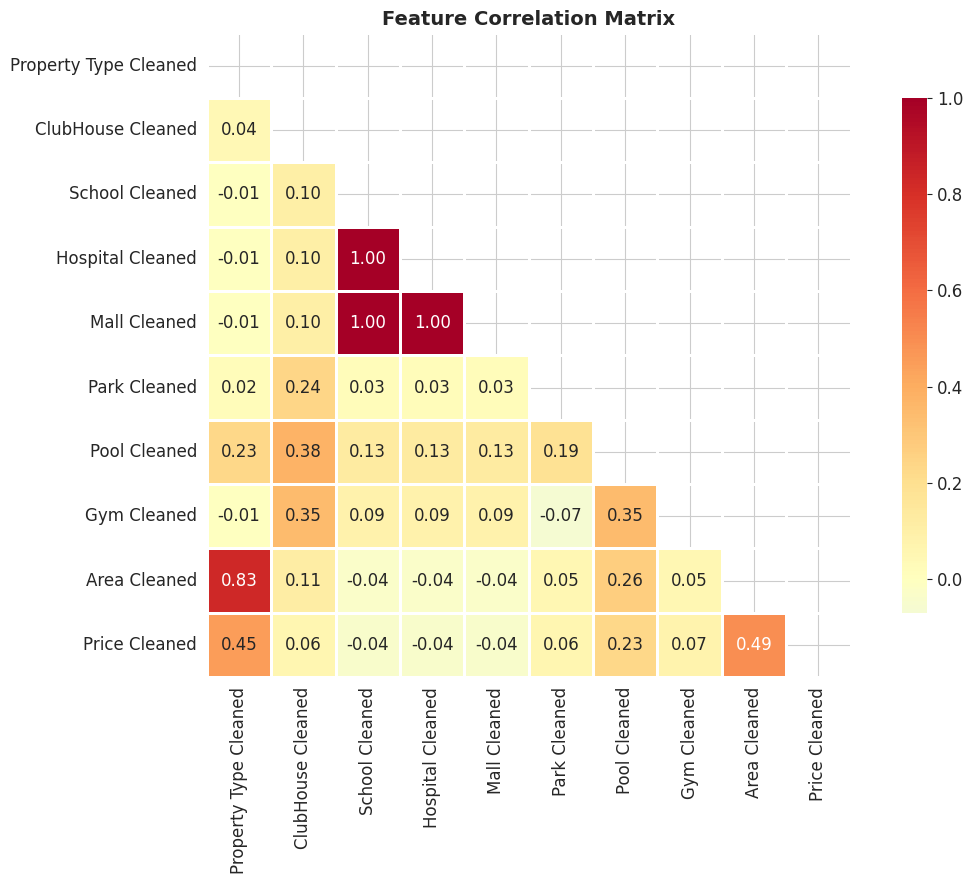


Top correlations with Price:
  Area Cleaned                        +0.493
  Property Type Cleaned               +0.450
  Pool Cleaned                        +0.231
  Gym Cleaned                         +0.073
  ClubHouse Cleaned                   +0.059
  Park Cleaned                        +0.056
  Mall Cleaned                        -0.039


In [ ]:
# ── 5.3 Correlation matrix (all numeric features) ──
numeric_df = df_clean.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=1, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations with price
price_corr = corr_matrix['Price Cleaned'].drop('Price Cleaned').abs().sort_values(ascending=False)
print("\nTop correlations with Price:")
for feat, val in price_corr.head(7).items():
    direction = "+" if corr_matrix.loc[feat, 'Price Cleaned'] > 0 else "-"
    print(f"  {feat:35s} {direction}{val:.3f}")

## 6. Outlier Detection & Treatment

Outliers can heavily distort linear regression. We use percentile clipping — conservative, retains all observations.

In [ ]:
# ── IQR-based detection ──
def detect_outliers_iqr(series, multiplier=1.5):
    """Detect outliers using IQR method. Returns mask, lower, upper bounds."""
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - multiplier * iqr, q3 + multiplier * iqr
    return (series < lower) | (series > upper), lower, upper

for col in ['Area Cleaned', 'Price Cleaned']:
    outlier_mask, lower, upper = detect_outliers_iqr(df_clean[col].dropna())
    print(f"{col}:")
    print(f"  IQR bounds: [{lower:.0f}, {upper:.0f}]")
    print(f"  Outliers: {outlier_mask.sum()} ({outlier_mask.sum()/len(outlier_mask)*100:.1f}%)")
    print()

Area Cleaned:
  IQR bounds: [122, 1582]
  Outliers: 15 (7.5%)

Price Cleaned:
  IQR bounds: [-20, 171]
  Outliers: 16 (8.0%)



Applying outlier clipping:
  Area Cleaned: clipped 20 values → range [422, 1663]
  Price Cleaned: clipped 18 values → range [36, 190]


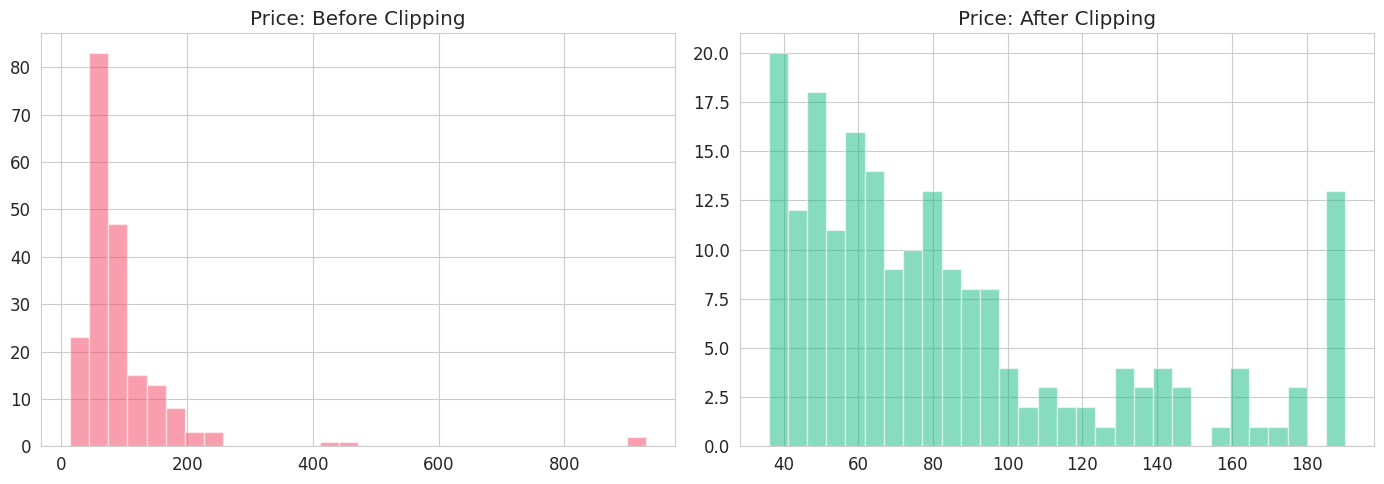

In [ ]:
# ── Clip at 5th and 95th percentiles ──
def clip_outliers(dataframe, col, lower_pct=5, upper_pct=95):
    """Clip values at specified percentiles."""
    lower = dataframe[col].quantile(lower_pct / 100)
    upper = dataframe[col].quantile(upper_pct / 100)
    before = ((dataframe[col] < lower) | (dataframe[col] > upper)).sum()
    dataframe[col] = dataframe[col].clip(lower=lower, upper=upper)
    print(f"  {col}: clipped {before} values → range [{lower:.0f}, {upper:.0f}]")
    return dataframe

# Visualize before/after
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['Price Cleaned'], bins=30, color='#f43f5e', alpha=0.5, label='Before', edgecolor='white')
axes[0].set_title('Price: Before Clipping')

print("Applying outlier clipping:")
for col in ['Area Cleaned', 'Price Cleaned']:
    df_clean = clip_outliers(df_clean, col)

axes[1].hist(df_clean['Price Cleaned'], bins=30, color='#10b981', alpha=0.5, label='After', edgecolor='white')
axes[1].set_title('Price: After Clipping')

plt.tight_layout()
plt.show()

## 7. Save Preprocessed Data

In [ ]:
# ── Save for Lab 2 ──
output_path = 'data_cleaned.csv'
df_clean.to_csv(output_path, index=False)
print(f"✅ Cleaned data saved to: {output_path}")
print(f"   Shape: {df_clean.shape[0]} rows × {df_clean.shape[1]} columns")
print(f"   Columns: {df_clean.columns.tolist()}")

✅ Cleaned data saved to: data_cleaned.csv
   Shape: 199 rows × 17 columns
   Columns: ['City', 'State', 'Country', 'Property Type Cleaned', 'Sub-Area Cleaned', 'Company Name Cleaned', 'TownShip Cleaned', 'Description Cleaned', 'ClubHouse Cleaned', 'School Cleaned', 'Hospital Cleaned', 'Mall Cleaned', 'Park Cleaned', 'Pool Cleaned', 'Gym Cleaned', 'Area Cleaned', 'Price Cleaned']


---

## 8. Conclusion & Next Steps

| Task | Key Takeaway |
|------|-------------|
| **Column-by-column inspection** | Never write a generic cleaner — inspect each column first |
| **Regex extraction** | Real datasets have numbers embedded in text; regex is essential |
| **Binary encoding** | Yes/No → 1/0 — seven amenity features now model-ready |
| **Before/after validation** | Always count unique values before and after cleaning |
| **Univariate EDA** | Price is right-skewed; area varies 10× between smallest and largest |
| **Multivariate EDA** | Area is the strongest price predictor; amenities add signal |
| **Outlier clipping** | Percentile-based clipping retains observations while reducing leverage |

### Try on Your Own
1. Explore the `TownShip Cleaned` column — which townships have the highest median price?
2. Create a "price per sq ft" feature and analyze its distribution
3. Try different clipping thresholds (1st/99th vs 5th/95th) — how does the distribution change?
4. The `Total TownShip Area in Acres` column has 149 missing values — how would you handle it?

---

**Next Lab:** Module 2, Lab 2 — NLP Feature Engineering + Target Encoding 📝